In [1]:
# MANTENIEMIENTO PREVENTIVO Y PREDICTIVO 
#DESCRIPCIÓN: Tomar datos de los sensores de las celdas MT y Transformadores Ormazabal 
#OBJETIVOS: Lograr predecir eventos anomalos antes de que sucedan Modelo de aprendizaje automatico Modeloestatico para predecir avería 
#APLICACION: para celdas MT verificar fallaerror averia por Machine Learnig

In [2]:

import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd


In [4]:
df = pd. read_csv("C:/Users/Cristina/Desktop/isra python/ai4i+2020+predictive+maintenance+dataset/ai4i2020.csv")
df.head()



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [5]:
#revisar si faltan datos 
# Acceder a la columna por nombre

# Conteo de valores nulos en toda la tabla
df.isnull().sum()



UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [6]:
#para ver conjunto de datos vemos desviacion estandar min - max 
df. describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

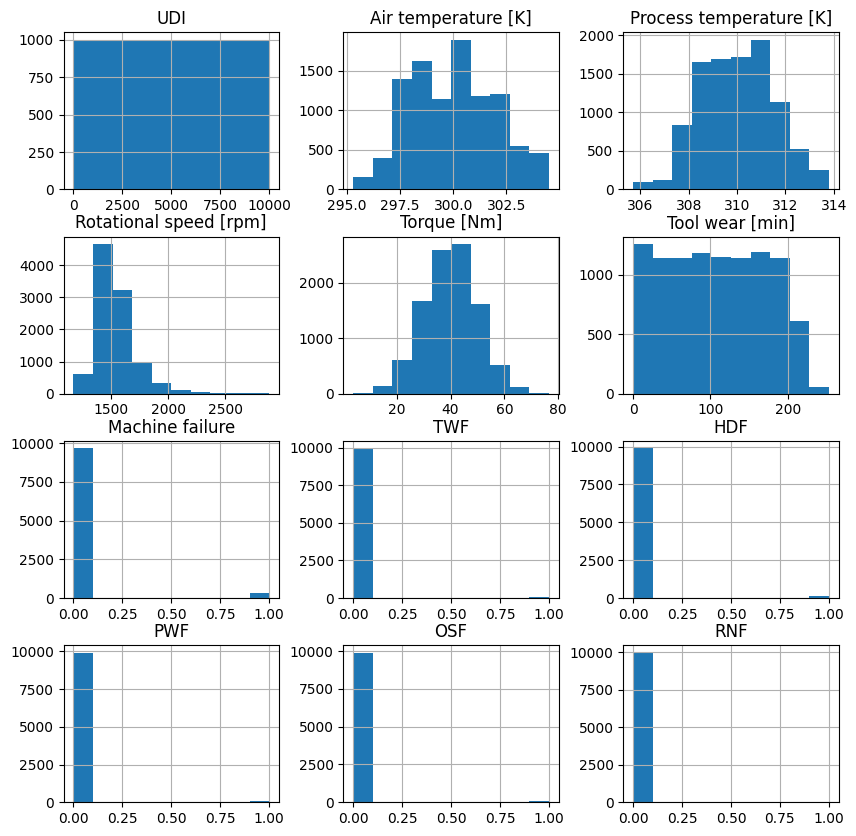

In [ ]:
#realizar la 1º grafica de los datos 
df.hist(figsize=(10,10))

#desestimar la figura 1 UDI

In [7]:
#distribucion de clases      # define un arreglo

df["Machine failure"]. unique() 
# 0 =no fallo   1= fallo 


array([0, 1])

In [8]:
# contador de valores
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: xlabel='Machine failure', ylabel='count'>

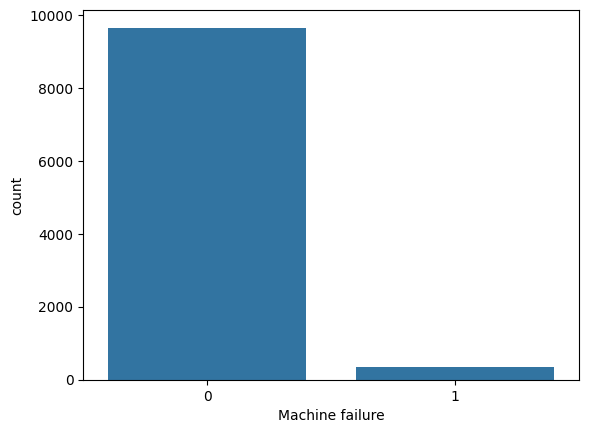

In [9]:
# recuento de puntos 
sns.countplot(x="Machine failure", data=df)
#vemos que el fallo es muy pequeño en comparacion con el no fallo 

In [ ]:
#tipo clase de relleno, consjunto de datos 
# tipos de fallo:  'TWF', 'HDF', 'PWF', 'OSF','RNF'
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [10]:
#columnas de relleno 
failure_cols =['TWF', 'HDF', 'PWF', 'OSF','RNF']
def classify_failure_type(row):
    for col in failure_cols:             #for es el  bucle
        if row[col] == 1:                # me retorna la columna 
          return col 
    return "no failure"

In [11]:
#aplicar columna en el eje X
def classify_failure_type(row):
    if row["Machine failure"] == 1:
        return "Fallo detectado"
    else:
        return "Sin fallo"

df["Failure Type"] =df.apply(classify_failure_type, axis=1)


In [12]:
#veriricar 
df["Failure Type"]

0       Sin fallo
1       Sin fallo
2       Sin fallo
3       Sin fallo
4       Sin fallo
          ...    
9995    Sin fallo
9996    Sin fallo
9997    Sin fallo
9998    Sin fallo
9999    Sin fallo
Name: Failure Type, Length: 10000, dtype: str

<Axes: xlabel='Failure Type', ylabel='count'>

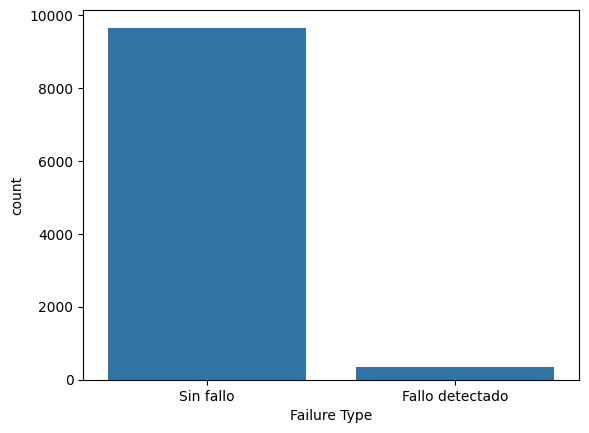

In [13]:
#trazado de cuentas 
sns.countplot(x="Failure Type", data=df)

<Axes: xlabel='Type', ylabel='count'>

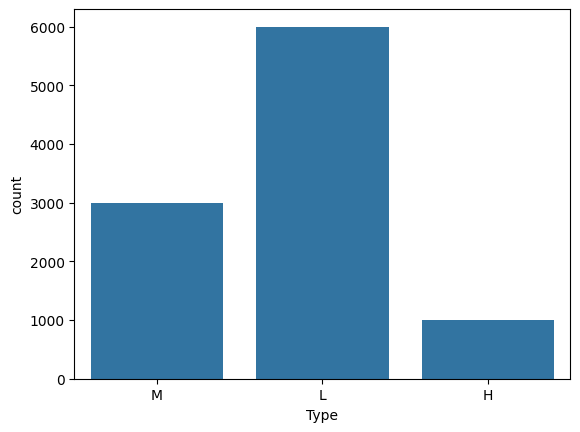

In [14]:
# equilibrar las tablas 
sns.countplot(x="Type", data=df)

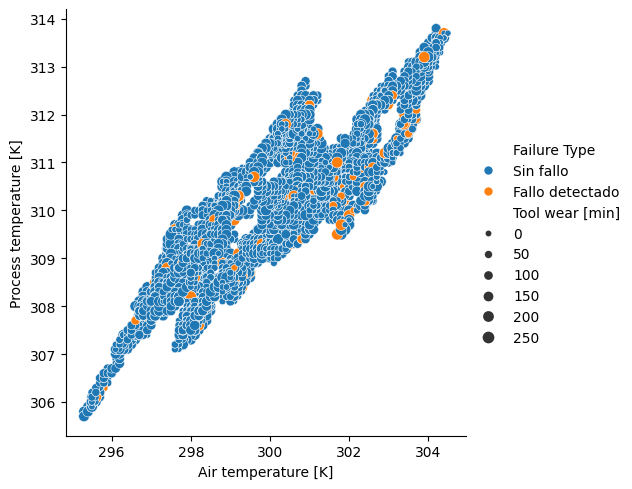

In [16]:
#graficar seaborn # grafico de tempartura 
sns.relplot(
    x='Air temperature [K]',
    y='Process temperature [K]',
    hue='Failure Type',
    size='Tool wear [min]',   # tamaño según desgaste de herramienta
    data=df
)





